In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs


# ============================================================
# Settings
# ============================================================

MASK_FILE = "/nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_masks_all_v20221025.nc"

MASK_VARS = [
    "open_ocean",
    "atlantic",
    "pacific",
    "indian",
    "southern",
    "arctic",
]


# ============================================================
# Helper functions
# ============================================================

def parse_region_names(da):
    """
    Parse region_name attribute:
    '1.Atlantic, 2.Pacific, ...'
    """
    attr = da.attrs.get("region_name", "")
    out = {}

    if not attr:
        return out

    for item in attr.split(","):
        item = item.strip()
        if "." not in item:
            continue

        key, name = item.split(".", 1)

        try:
            out[int(key.strip())] = name.strip()
        except ValueError:
            pass

    return out


def get_region_ids(da):
    vals = np.unique(da.values)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return sorted(vals.astype(int))


def weighted_centroid(lon, lat, mask):
    """
    Area-weighted centroid for label position.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    if np.nansum(weights) == 0:
        return np.nan, np.nan

    # Circular mean longitude
    lon_rad = np.deg2rad(lon2d)
    x = np.nansum(weights * np.cos(lon_rad)) / np.nansum(weights)
    y = np.nansum(weights * np.sin(lon_rad)) / np.nansum(weights)

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / np.nansum(weights)

    return lon_c, lat_c


def lon_to_180(lon):
    return ((lon + 180) % 360) - 180


def add_basic_map(ax, ds):
    """
    Add simple coast-like contour using seamask.
    This avoids Cartopy coastline download problems on HPC.
    """
    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=9)

    if "seamask" in ds:
        ax.contour(
            ds["lon"],
            ds["lat"],
            ds["seamask"],
            levels=[0.5],
            colors="k",
            linewidths=0.4,
            transform=ccrs.PlateCarree(),
        )


def plot_reccap2_mask(ds, varname):
    da = ds[varname]

    lon = ds["lon"].values
    lat = ds["lat"].values

    region_ids = get_region_ids(da)
    region_names = parse_region_names(da)

    plot_da = da.where(da > 0)

    cmap = plt.get_cmap("tab20", len(region_ids)).copy()
    cmap.set_bad((1, 1, 1, 0))

    bounds = np.arange(min(region_ids) - 0.5, max(region_ids) + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig = plt.figure(figsize=(12, 5.5))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    im = ax.pcolormesh(
        lon,
        lat,
        plot_da,
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    add_basic_map(ax, ds)

    ax.set_title(f"RECCAP2 mask: {varname}", fontsize=15)

    # Add region number labels
    for rid in region_ids:
        mask = da.values == rid
        lon_c, lat_c = weighted_centroid(lon, lat, mask)

        if np.isfinite(lon_c) and np.isfinite(lat_c):
            ax.text(
                lon_to_180(lon_c),
                lat_c,
                str(rid),
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.15",
                ),
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.06,
        shrink=0.95,
        ticks=region_ids,
    )

    labels = [
        f"{rid}: {region_names.get(rid, f'{varname} region {rid}')}"
        for rid in region_ids
    ]
    cbar.ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)

    plt.tight_layout()
    plt.show()

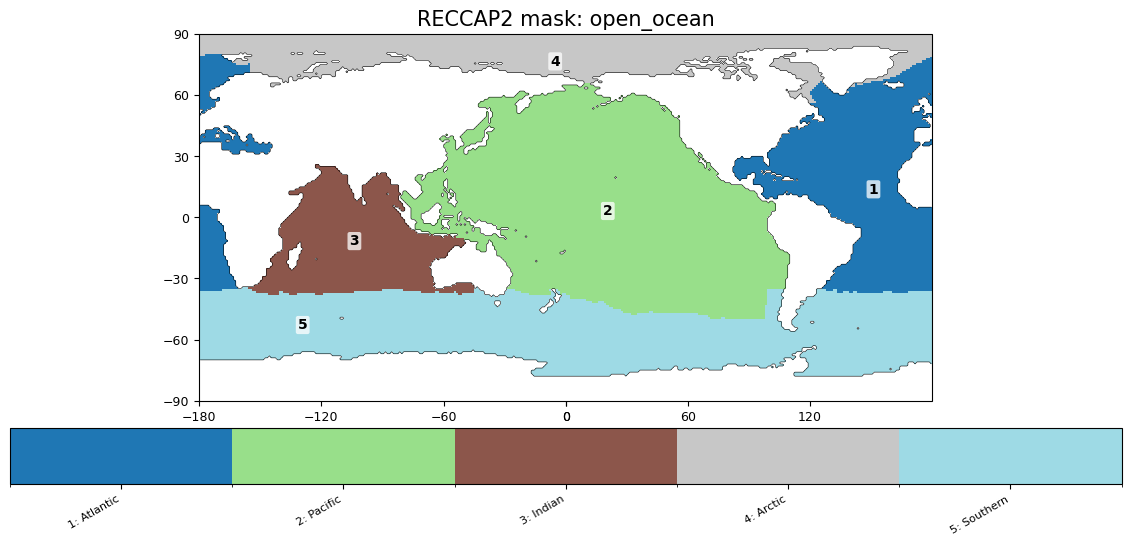

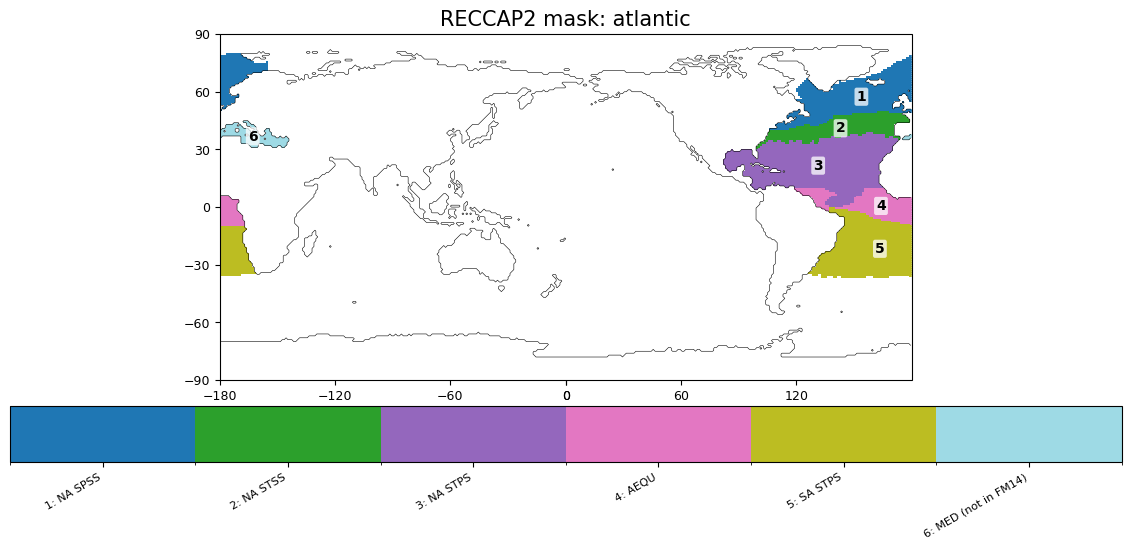

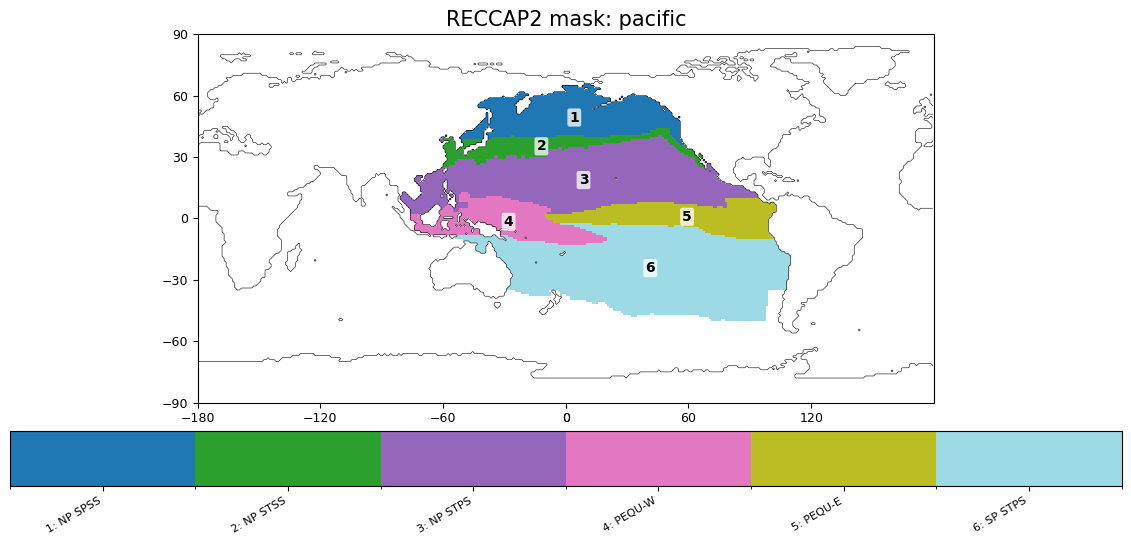

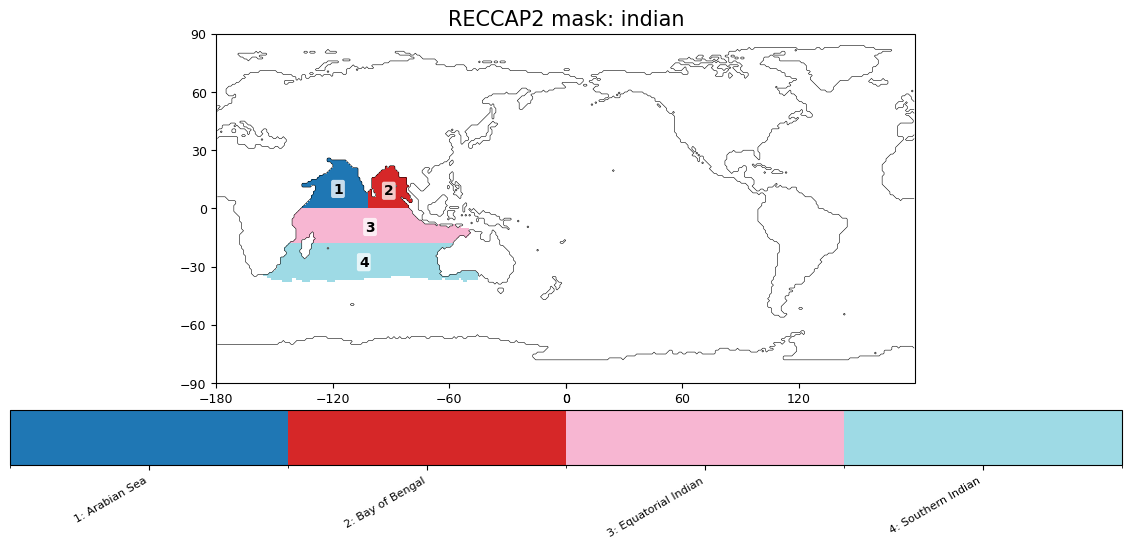

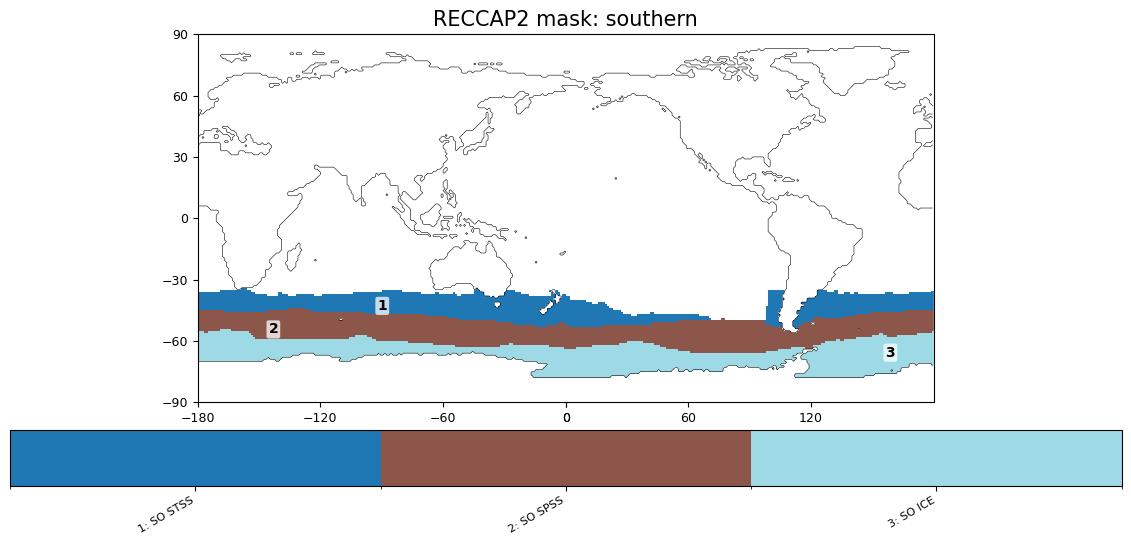

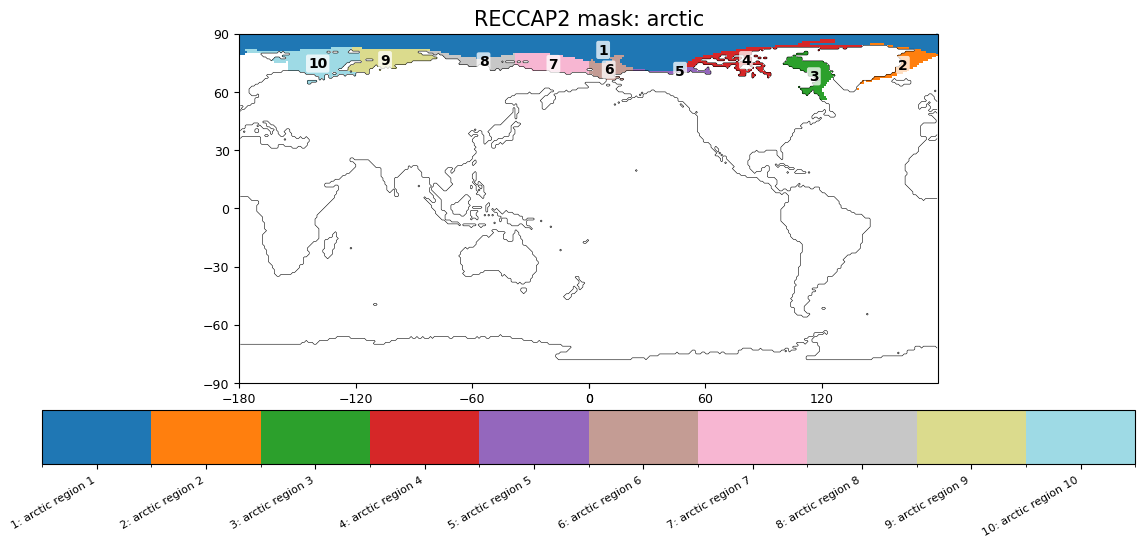

In [3]:
ds = xr.open_dataset(MASK_FILE)

for varname in MASK_VARS:
    plot_reccap2_mask(ds, varname)

In [4]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs


# ============================================================
# Settings
# ============================================================

MASK_FILE = "/nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_masks_all_v20221025.nc"

BASIN_VARS = [
    "atlantic",
    "pacific",
    "indian",
    "southern",
    "arctic",
]


# ============================================================
# Helper functions
# ============================================================

def parse_region_names(da):
    """
    Parse region_name attribute like:
    '1.NA SPSS, 2.NA STSS, ...'
    into {1: 'NA SPSS', 2: 'NA STSS', ...}
    """
    attr = da.attrs.get("region_name", "")
    out = {}

    if not attr:
        return out

    for item in attr.split(","):
        item = item.strip()
        if "." not in item:
            continue

        key, name = item.split(".", 1)
        try:
            out[int(key.strip())] = name.strip()
        except ValueError:
            pass

    return out


def get_region_ids(da):
    vals = np.unique(da.values)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return sorted(vals.astype(int))


def weighted_centroid(lon, lat, mask):
    """
    Area-weighted centroid for label placement.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    if np.nansum(weights) == 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)
    x = np.nansum(weights * np.cos(lon_rad)) / np.nansum(weights)
    y = np.nansum(weights * np.sin(lon_rad)) / np.nansum(weights)

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / np.nansum(weights)

    return lon_c, lat_c


def lon_to_180(lon):
    return ((lon + 180) % 360) - 180


def add_basic_map(ax, ds):
    """
    Draw a simple coastline-like contour from seamask
    to avoid Cartopy download issues on HPC.
    """
    ax.set_global()
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=9)

    if "seamask" in ds:
        ax.contour(
            ds["lon"],
            ds["lat"],
            ds["seamask"],
            levels=[0.5],
            colors="k",
            linewidths=0.4,
            transform=ccrs.PlateCarree(),
        )


def build_combined_mask(ds, basin_vars):
    """
    Combine basin-specific masks into one map with unique integer codes.
    """
    combined = xr.full_like(ds["seamask"], fill_value=0, dtype=np.int16)

    rows = []
    combined_code = 1

    for basin in basin_vars:
        da = ds[basin]
        region_ids = get_region_ids(da)
        region_names = parse_region_names(da)

        for rid in region_ids:
            combined = combined.where(da != rid, combined_code)

            rows.append(
                {
                    "combined_code": combined_code,
                    "basin": basin,
                    "original_region_id": rid,
                    "region_name": region_names.get(rid, f"{basin} region {rid}")
                }
            )

            combined_code += 1

    region_table = pd.DataFrame(rows)
    return combined, region_table


def plot_combined_reccap2_map(ds, combined, region_table):
    lon = ds["lon"].values
    lat = ds["lat"].values

    plot_da = combined.where(combined > 0)
    codes = region_table["combined_code"].values

    cmap = plt.get_cmap("tab20", len(codes)).copy()
    cmap.set_bad((1, 1, 1, 0))

    bounds = np.arange(codes.min() - 0.5, codes.max() + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig = plt.figure(figsize=(14, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    im = ax.pcolormesh(
        lon,
        lat,
        plot_da,
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    add_basic_map(ax, ds)
    ax.set_title("Combined RECCAP2 basin masks", fontsize=15)

    # Add labels on the map
    for code in codes:
        mask = combined.values == code
        lon_c, lat_c = weighted_centroid(lon, lat, mask)

        if np.isfinite(lon_c) and np.isfinite(lat_c):
            ax.text(
                lon_to_180(lon_c),
                lat_c,
                str(code),
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.15",
                ),
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.06,
        shrink=0.95,
        ticks=codes,
    )
    cbar.set_label("Combined region code", fontsize=10)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

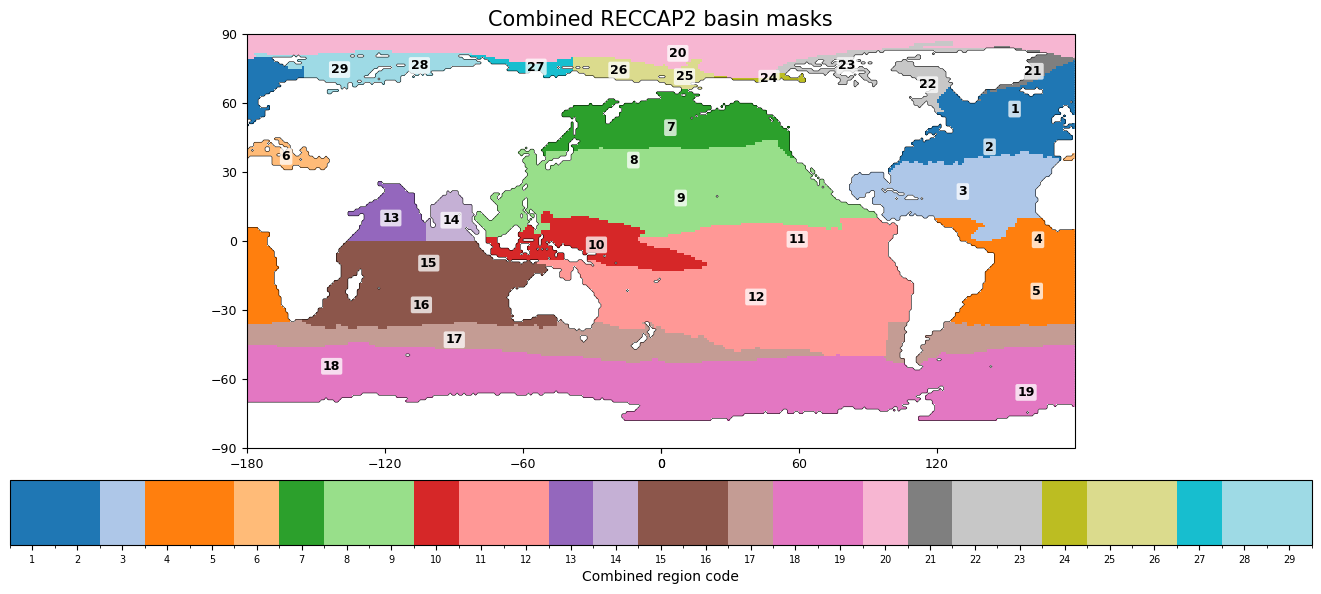

,combined_code,basin,original_region_id,region_name
0,1,atlantic,1,NA SPSS
1,2,atlantic,2,NA STSS
2,3,atlantic,3,NA STPS
3,4,atlantic,4,AEQU
4,5,atlantic,5,SA STPS
5,6,atlantic,6,MED (not in FM14)
6,7,pacific,1,NP SPSS
7,8,pacific,2,NP STSS
8,9,pacific,3,NP STPS
9,10,pacific,4,PEQU-W


In [5]:
ds = xr.open_dataset(MASK_FILE)

combined_mask, region_table = build_combined_mask(ds, BASIN_VARS)

plot_combined_reccap2_map(ds, combined_mask, region_table)

region_table

In [10]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs


# ============================================================
# Settings
# ============================================================

MASK_FILE = "/nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_masks_all_v20221025.nc"

# Arctic is excluded entirely, so not included here
BASIN_VARS = [
    "atlantic",
    "pacific",
    "indian",
    "southern",
]

# region IDs to exclude from each basin
# EXCLUDE_REGIONS = {
#     "atlantic": [1, 6],   # 1.NA SPSS, 6.MED
#     "southern": [3],      # 3.SO ICE
#     "pacific": [],
#     "indian": [],
#     # arctic excluded entirely by not including it in BASIN_VARS
# }
EXCLUDE_REGIONS = {
    "atlantic": [6],   # 1.NA SPSS, 6.MED
    "southern": [3],      # 3.SO ICE
    "pacific": [],
    "indian": [],
    # arctic excluded entirely by not including it in BASIN_VARS
}


# ============================================================
# Helper functions
# ============================================================

def parse_region_names(da):
    attr = da.attrs.get("region_name", "")
    out = {}

    if not attr:
        return out

    for item in attr.split(","):
        item = item.strip()
        if "." not in item:
            continue

        key, name = item.split(".", 1)
        try:
            out[int(key.strip())] = name.strip()
        except ValueError:
            pass

    return out


def get_region_ids(da):
    vals = np.unique(da.values)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return sorted(vals.astype(int))


def weighted_centroid(lon, lat, mask):
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    if np.nansum(weights) == 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)
    x = np.nansum(weights * np.cos(lon_rad)) / np.nansum(weights)
    y = np.nansum(weights * np.sin(lon_rad)) / np.nansum(weights)

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / np.nansum(weights)

    return lon_c, lat_c


def lon_to_180(lon):
    return ((lon + 180) % 360) - 180


def add_basic_map(ax, ds):
    ax.set_global()
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=9)

    if "seamask" in ds:
        ax.contour(
            ds["lon"],
            ds["lat"],
            ds["seamask"],
            levels=[0.5],
            colors="k",
            linewidths=0.4,
            transform=ccrs.PlateCarree(),
        )


# ============================================================
# Build combined mask with exclusions
# ============================================================

def build_combined_mask(ds, basin_vars, exclude_regions):
    combined = xr.full_like(ds["seamask"], fill_value=0, dtype=np.int16)

    rows = []
    combined_code = 1

    for basin in basin_vars:
        da = ds[basin]
        region_ids = get_region_ids(da)
        region_names = parse_region_names(da)

        excluded = exclude_regions.get(basin, [])

        for rid in region_ids:
            if rid in excluded:
                continue

            combined = combined.where(da != rid, combined_code)

            rows.append(
                {
                    "combined_code": combined_code,
                    "basin": basin,
                    "original_region_id": rid,
                    "region_name": region_names.get(rid, f"{basin} region {rid}")
                }
            )

            combined_code += 1

    region_table = pd.DataFrame(rows)
    return combined, region_table


# ============================================================
# Plot
# ============================================================

def plot_combined_reccap2_map(ds, combined, region_table):
    lon = ds["lon"].values
    lat = ds["lat"].values

    plot_da = combined.where(combined > 0)
    codes = region_table["combined_code"].values

    cmap = plt.get_cmap("tab20", len(codes)).copy()
    cmap.set_bad((1, 1, 1, 0))

    bounds = np.arange(codes.min() - 0.5, codes.max() + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig = plt.figure(figsize=(14, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    im = ax.pcolormesh(
        lon,
        lat,
        plot_da,
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    add_basic_map(ax, ds)
    ax.set_title(
        "Combined RECCAP2 basin masks\n"
        # "(excluding Southern SO ICE, Atlantic NA SPSS & MED, and all Arctic)",
        "(excluding Southern SO ICE, Atlantic MED, and all Arctic)",
        fontsize=14
    )

    for code in codes:
        mask = combined.values == code
        lon_c, lat_c = weighted_centroid(lon, lat, mask)

        if np.isfinite(lon_c) and np.isfinite(lat_c):
            ax.text(
                lon_to_180(lon_c),
                lat_c,
                str(code),
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.15",
                ),
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.06,
        shrink=0.95,
        ticks=codes,
    )
    cbar.set_label("Combined region code", fontsize=10)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

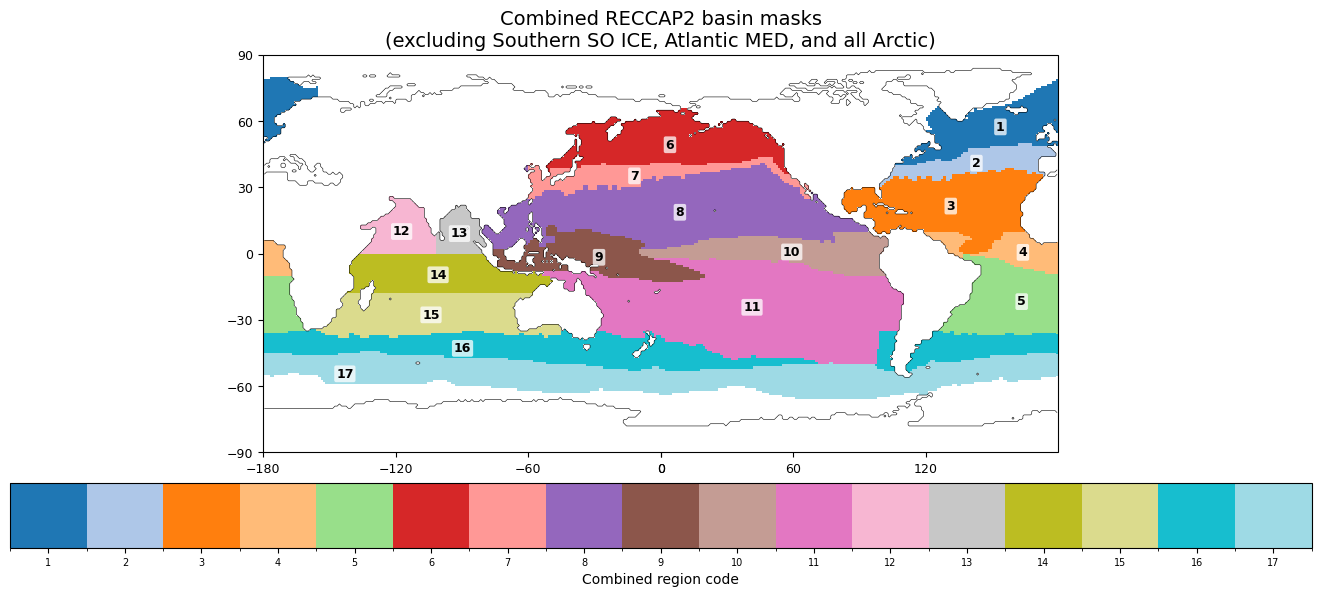

,combined_code,basin,original_region_id,region_name
0,1,atlantic,1,NA SPSS
1,2,atlantic,2,NA STSS
2,3,atlantic,3,NA STPS
3,4,atlantic,4,AEQU
4,5,atlantic,5,SA STPS
5,6,pacific,1,NP SPSS
6,7,pacific,2,NP STSS
7,8,pacific,3,NP STPS
8,9,pacific,4,PEQU-W
9,10,pacific,5,PEQU-E


In [11]:
ds = xr.open_dataset(MASK_FILE)

combined_mask, region_table = build_combined_mask(
    ds,
    BASIN_VARS,
    EXCLUDE_REGIONS,
)

plot_combined_reccap2_map(ds, combined_mask, region_table)

region_table

In [12]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs


# ============================================================
# Settings
# ============================================================

MASK_FILE = "/nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_masks_all_v20221025.nc"

# Arctic is excluded entirely, so not included here
BASIN_VARS = [
    "atlantic",
    "pacific",
    "indian",
    "southern",
]

# region IDs to exclude from each basin
EXCLUDE_REGIONS = {
    "atlantic": [1, 6],      # 1.NA SPSS, 6.MED
    "pacific": [1],          # 1.NP SPSS
    "indian": [],
    "southern": [1, 2, 3],   # 1.SO STSS, 2.SO SPSS, 3.SO ICE
}


# ============================================================
# Plot
# ============================================================

def plot_combined_reccap2_map(ds, combined, region_table):
    lon = ds["lon"].values
    lat = ds["lat"].values

    plot_da = combined.where(combined > 0)
    codes = region_table["combined_code"].values

    cmap = plt.get_cmap("tab20", len(codes)).copy()
    cmap.set_bad((1, 1, 1, 0))

    bounds = np.arange(codes.min() - 0.5, codes.max() + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig = plt.figure(figsize=(14, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    im = ax.pcolormesh(
        lon,
        lat,
        plot_da,
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    add_basic_map(ax, ds)
    ax.set_title(
        "Combined RECCAP2 basin masks\n"
        "(excluding conservative high-latitude/subpolar regions)",
        fontsize=14
    )

    for code in codes:
        mask = combined.values == code
        lon_c, lat_c = weighted_centroid(lon, lat, mask)

        if np.isfinite(lon_c) and np.isfinite(lat_c):
            ax.text(
                lon_to_180(lon_c),
                lat_c,
                str(code),
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.15",
                ),
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.06,
        shrink=0.95,
        ticks=codes,
    )
    cbar.set_label("Combined region code", fontsize=10)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

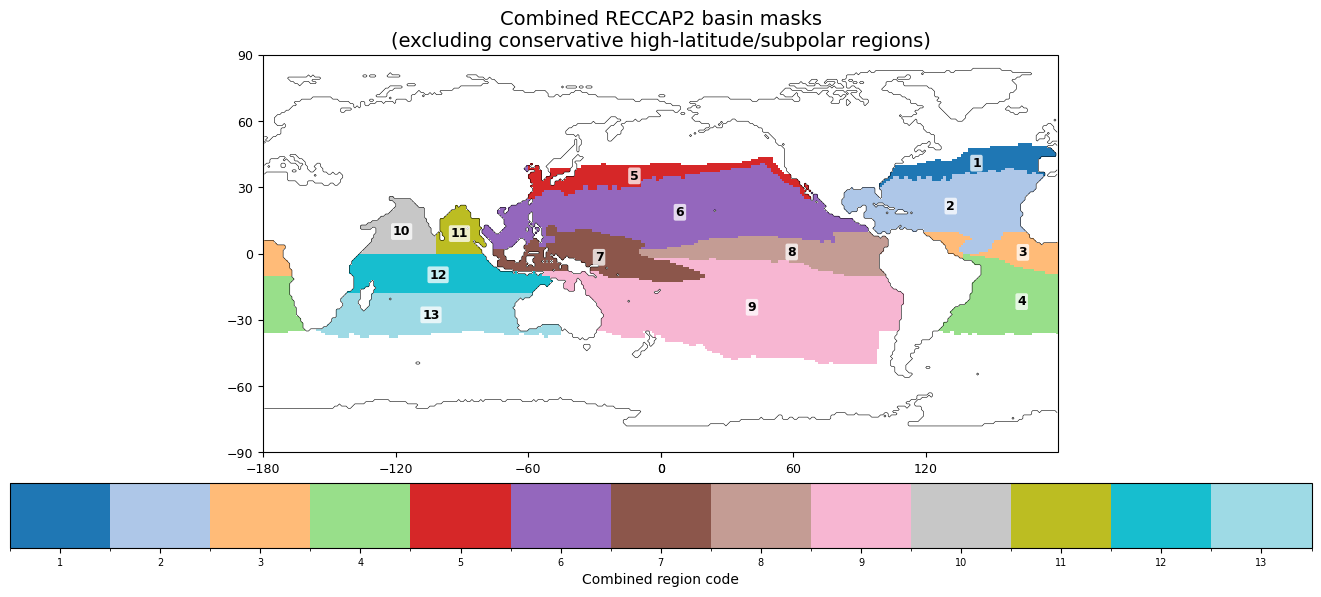

,combined_code,basin,original_region_id,region_name
0,1,atlantic,2,NA STSS
1,2,atlantic,3,NA STPS
2,3,atlantic,4,AEQU
3,4,atlantic,5,SA STPS
4,5,pacific,2,NP STSS
5,6,pacific,3,NP STPS
6,7,pacific,4,PEQU-W
7,8,pacific,5,PEQU-E
8,9,pacific,6,SP STPS
9,10,indian,1,Arabian Sea


In [13]:
ds = xr.open_dataset(MASK_FILE)

combined_mask_conservative, region_table_conservative = build_combined_mask(
    ds,
    BASIN_VARS,
    EXCLUDE_REGIONS,
)

plot_combined_reccap2_map(
    ds,
    combined_mask_conservative,
    region_table_conservative
)

region_table_conservative

In [14]:
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
from datetime import date


# ============================================================
# Input / output
# ============================================================

MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/RECCAP2/"
    "RECCAP2_region_masks_all_v20221025.nc"
)

OUT_FILE = MASK_FILE.parent / "RECCAP2_region_mask_13regions_conservative_v20260707.nc"


# ============================================================
# Region selection
# ============================================================

BASIN_VARS = [
    "atlantic",
    "pacific",
    "indian",
    "southern",
]

# Conservative exclusion
EXCLUDE_REGIONS = {
    "atlantic": [1, 6],      # 1.NA SPSS, 6.MED
    "pacific": [1],          # 1.NP SPSS
    "indian": [],
    "southern": [1, 2, 3],   # 1.SO STSS, 2.SO SPSS, 3.SO ICE
}


# ============================================================
# Helper functions
# ============================================================

def parse_region_names(da):
    """
    Parse region_name attribute:
    '1.NA SPSS, 2.NA STSS, ...'
    """
    attr = da.attrs.get("region_name", "")
    out = {}

    if not attr:
        return out

    for item in attr.split(","):
        item = item.strip()

        if "." not in item:
            continue

        key, name = item.split(".", 1)

        try:
            out[int(key.strip())] = name.strip()
        except ValueError:
            pass

    return out


def get_region_ids(da):
    vals = np.unique(da.values)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return sorted(vals.astype(int))


def build_13region_mask(ds, basin_vars, exclude_regions):
    """
    Build a new combined RECCAP2 mask.

    Output:
        0   = excluded / outside selected regions
        1-13 = selected conservative RECCAP2 regions
    """
    combined = xr.full_like(ds["seamask"], fill_value=0, dtype=np.int8)

    rows = []
    combined_code = 1

    for basin in basin_vars:
        da = ds[basin]
        region_ids = get_region_ids(da)
        region_names = parse_region_names(da)
        excluded = exclude_regions.get(basin, [])

        for rid in region_ids:
            if rid in excluded:
                continue

            region_name = region_names.get(rid, f"{basin} region {rid}")

            combined = combined.where(da != rid, combined_code)

            rows.append(
                {
                    "combined_code": combined_code,
                    "basin": basin,
                    "original_region_id": rid,
                    "region_name": region_name,
                }
            )

            combined_code += 1

    region_table = pd.DataFrame(rows)

    if len(region_table) != 13:
        raise ValueError(f"Expected 13 regions, but got {len(region_table)}")

    return combined, region_table


# ============================================================
# Main
# ============================================================

ds = xr.open_dataset(MASK_FILE)

region_mask, region_table = build_13region_mask(
    ds,
    BASIN_VARS,
    EXCLUDE_REGIONS,
)

print(region_table.to_string(index=False))


# ============================================================
# Create output dataset
# ============================================================

# Attribute string like:
# "1.NA STSS, 2.NA STPS, ..."
region_name_attr = ", ".join(
    [
        f"{row.combined_code}.{row.region_name}"
        for row in region_table.itertuples(index=False)
    ]
)

# More detailed provenance string
region_source_attr = ", ".join(
    [
        f"{row.combined_code}.{row.basin}:{row.original_region_id}.{row.region_name}"
        for row in region_table.itertuples(index=False)
    ]
)

excluded_attr = (
    "atlantic: 1.NA SPSS, 6.MED; "
    "pacific: 1.NP SPSS; "
    "southern: 1.SO STSS, 2.SO SPSS, 3.SO ICE; "
    "arctic: all excluded"
)

out_ds = xr.Dataset(
    data_vars={
        "region_mask": region_mask.astype("int8"),
    },
    coords={
        "lat": ds["lat"],
        "lon": ds["lon"],
    },
    attrs=ds.attrs.copy(),
)

# Variable attributes
out_ds["region_mask"].attrs.update(
    {
        "long_name": "Conservative 13-region RECCAP2 ocean mask",
        "description": (
            "Combined RECCAP2 regional mask after excluding selected "
            "high-latitude, ice, Mediterranean, and Arctic regions. "
            "0 indicates excluded or non-selected areas; 1-13 indicate "
            "selected RECCAP2 regions."
        ),
        "units": "1",
        "valid_min": np.int8(0),
        "valid_max": np.int8(13),
        "region_name": region_name_attr,
        "region_source": region_source_attr,
        "excluded_regions": excluded_attr,
    }
)

# Coordinate attributes are preserved automatically, but keep explicitly
out_ds["lat"].attrs = ds["lat"].attrs.copy()
out_ds["lon"].attrs = ds["lon"].attrs.copy()

# Update global attributes
out_ds.attrs.update(
    {
        "title": "Conservative 13-region RECCAP2 ocean mask",
        "description": (
            "Conservative combined RECCAP2 ocean mask derived from "
            "RECCAP2_region_masks_all_v20221025.nc. "
            "The mask combines Atlantic, Pacific, Indian, and Southern "
            "subregions after excluding Atlantic NA SPSS and MED, "
            "Pacific NP SPSS, all Southern Ocean subregions, and all Arctic."
        ),
        "source_file": str(MASK_FILE),
        "created_by": "custom script based on RECCAP2 region masks",
        "date_created": date.today().isoformat(),
    }
)


# ============================================================
# Save netCDF
# ============================================================

encoding = {
    "region_mask": {
        "dtype": "int8",
        "_FillValue": None,
        "zlib": True,
        "complevel": 4,
    },
    "lat": {
        "dtype": "float64",
        "_FillValue": None,
    },
    "lon": {
        "dtype": "float64",
        "_FillValue": None,
    },
}

out_ds.to_netcdf(OUT_FILE, encoding=encoding)

print(f"\nSaved: {OUT_FILE}")

 combined_code    basin  original_region_id       region_name
             1 atlantic                   2           NA STSS
             2 atlantic                   3           NA STPS
             3 atlantic                   4              AEQU
             4 atlantic                   5           SA STPS
             5  pacific                   2           NP STSS
             6  pacific                   3           NP STPS
             7  pacific                   4            PEQU-W
             8  pacific                   5            PEQU-E
             9  pacific                   6           SP STPS
            10   indian                   1       Arabian Sea
            11   indian                   2     Bay of Bengal
            12   indian                   3 Equatorial Indian
            13   indian                   4   Southern Indian

Saved: /nird/datalake/NS11071K/users/yongyub/RECCAP2/RECCAP2_region_mask_13regions_conservative_v20260707.nc
